In [1]:
symbol = 'TQQQ'

import yfinance
hist = yfinance.download(tickers=symbol,period="7d",interval="1m")

[*********************100%***********************]  1 of 1 completed


In [2]:
# change column name to lower case and without space.
# option 1
new_col_list = []
for i in hist.columns:
    new_col_list.append(i.lower().replace(" ", ""))
hist.columns = new_col_list

In [3]:
# option 2 
# dataframe.columns.values == array
# dataframe.columns == index
# pandas does not want pd.Indexs to be mutable
for i,j in enumerate(hist.columns):
    hist.columns.values[i] = j.lower().replace(" ", "")


In [4]:
hist['close'].rolling(20).mean()

Datetime
2022-09-22 09:30:00-04:00          NaN
2022-09-22 09:31:00-04:00          NaN
2022-09-22 09:32:00-04:00          NaN
2022-09-22 09:33:00-04:00          NaN
2022-09-22 09:34:00-04:00          NaN
                               ...    
2022-09-30 15:32:00-04:00    19.761395
2022-09-30 15:33:00-04:00    19.760600
2022-09-30 15:34:00-04:00    19.760350
2022-09-30 15:46:00-04:00    19.759680
2022-09-30 15:50:03-04:00    19.752460
Name: close, Length: 2697, dtype: float64

In [5]:
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt

def get_bollinger_bands(data, rate=20):
    sma = data['close'].rolling(rate).mean()
    std = data['close'].rolling(rate).std()
    bollinger_up = pd.Series(sma + std * 2, name = 'bollinger_up_' + str(rate)) # Calculate top band
    bollinger_down = pd.Series(sma - std * 2, name ='bollinger_down_' + str(rate)) # Calculate bottom band
    data = data.join([bollinger_up,bollinger_down])
    return data

# symbol = 'AAPL'
# df = pdr.DataReader(symbol, 'yahoo', '2014-07-01', '2015-07-01')
# df.index = np.arange(df.shape[0])




In [6]:
def SMA(data, ndays=20): 
    SMA = pd.Series(data['close'].rolling(ndays).mean(), name = 'SMA_'+ str(ndays)) 
    data = data.join(SMA) 
    return data

In [7]:
def EWMA(data, ndays=20): 
    EMA = pd.Series(data['close'].ewm(span = ndays, min_periods = ndays - 1).mean(), 
                 name = 'EWMA_' + str(ndays)) 
    data = data.join(EMA) 
    return data

In [8]:
def rsi(data, periods = 20):
    
    close_delta = data['close'].diff()

    # Make two series: one for lower closes and one for higher closes
    up = close_delta.clip(lower=0)
    down = -1 * close_delta.clip(upper=0)
    
    ma_up = up.ewm(com = periods - 1, adjust=True, min_periods = periods).mean()
    ma_down = down.ewm(com = periods - 1, adjust=True, min_periods = periods).mean()

    rsi = ma_up / ma_down
    rsi = 100 - (100/(1 + rsi))
    RSI = pd.Series(rsi, name='RSI_' + str(periods))
    data = data.join(RSI)
    return data

In [9]:
def gain(x):
    return ((x > 0) * x).sum()


def loss(x):
    return ((x < 0) * x).sum()


# Calculate money flow index
def mfi(data, n=20):
    high = data['high']
    low = data['low']
    close = data['close']
    volume = data['volume']
    typical_price = (high + low + close)/3
    money_flow = typical_price * volume
    mf_sign = np.where(typical_price > typical_price.shift(1), 1, -1)
    signed_mf = money_flow * mf_sign
    mf_avg_gain = signed_mf.rolling(n).apply(gain, raw=True)
    mf_avg_loss = signed_mf.rolling(n).apply(loss, raw=True)
    mfi = (100 - (100 / (1 + (mf_avg_gain / abs(mf_avg_loss)))))
    MFI = pd.Series(mfi, name='MFI_' + str(n))
    data = data.join(MFI)
    return data

In [10]:
def percent_change(data, level = 'close'):
    PER = pd.Series((data[level] - data[level].shift(1))/data[level].shift(1)*100, name = 'PER_'+level)
    data = data.join(PER)
    return data
    

In [11]:
hist = mfi(hist,14)

In [12]:
hist = rsi(hist, 14)

In [13]:
hist = get_bollinger_bands(hist, 14)

In [14]:
hist = percent_change(hist, 'close')

In [15]:
hist = percent_change(hist, 'volume')

In [16]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,,,,,
2022-09-22 09:30:00-04:00,22.850000,23.080000,22.799999,23.074499,23.074499,15332963,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-22 09:31:00-04:00,23.075001,23.080000,22.959999,23.031099,23.031099,1141120,NaN,NaN,NaN,NaN,-0.188086,-92.557733
2022-09-22 09:32:00-04:00,23.025000,23.069599,22.910000,22.990000,22.990000,923174,NaN,NaN,NaN,NaN,-0.178452,-19.099306
2022-09-22 09:33:00-04:00,23.050301,23.087601,23.049999,23.079300,23.079300,917836,NaN,NaN,NaN,NaN,0.388430,-0.578223
2022-09-22 09:34:00-04:00,23.000000,23.080000,23.000000,23.029699,23.029699,338528,NaN,NaN,NaN,NaN,-0.214914,-63.116722
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30 15:32:00-04:00,19.764999,19.770000,19.733400,19.737801,19.737801,1077597,49.851148,46.077971,19.899094,19.628178,-0.441353,-13.815062
2022-09-30 15:33:00-04:00,19.735001,19.779900,19.719999,19.719999,19.719999,661752,43.864025,44.983654,19.896126,19.622289,-0.090189,-38.590029
2022-09-30 15:34:00-04:00,19.715000,19.750000,19.700001,19.740000,19.740000,401264,39.264698,46.520431,19.891700,19.619572,0.101422,-39.363387


2022-09-22


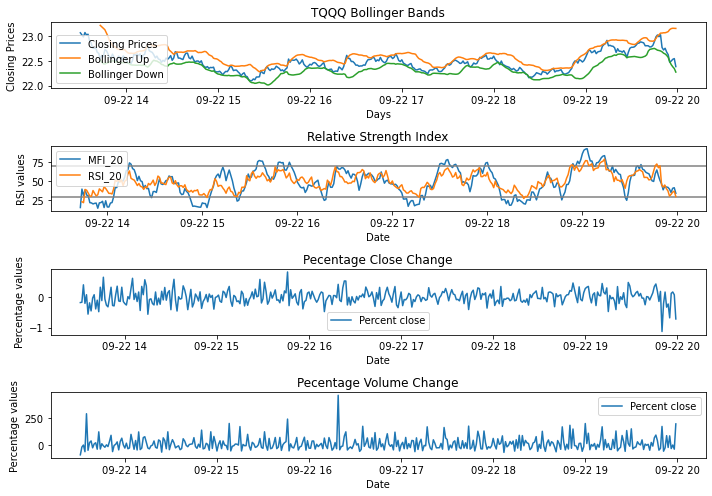

2022-09-23


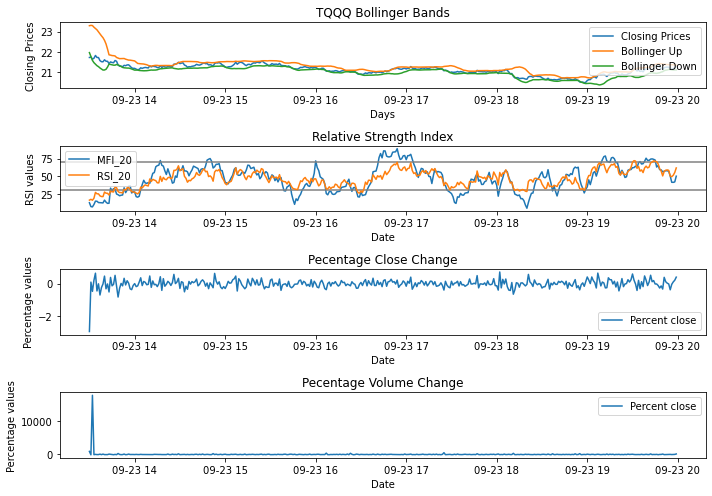

2022-09-26


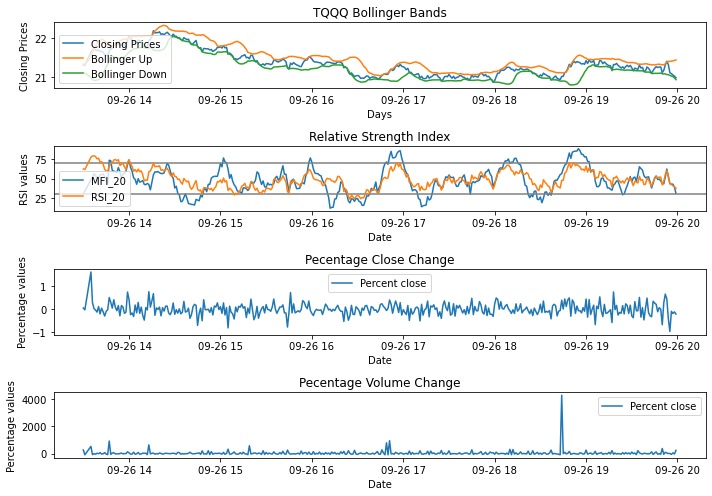

2022-09-27


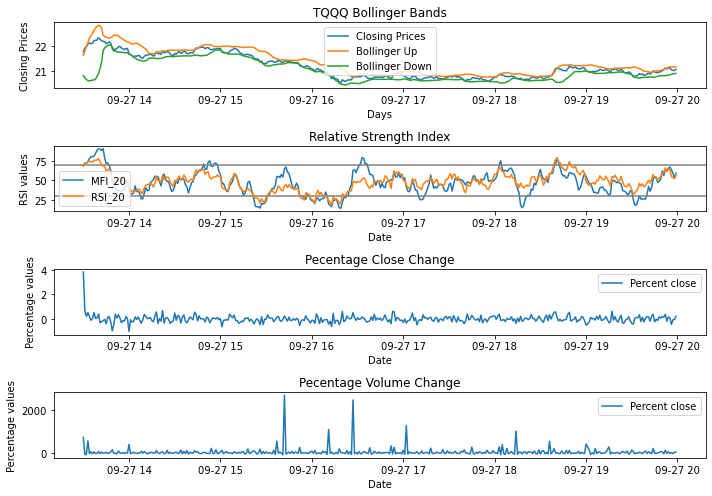

2022-09-28


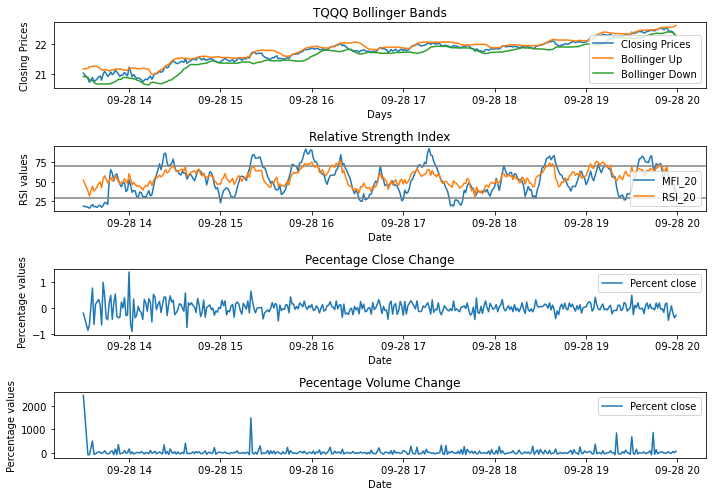

2022-09-29


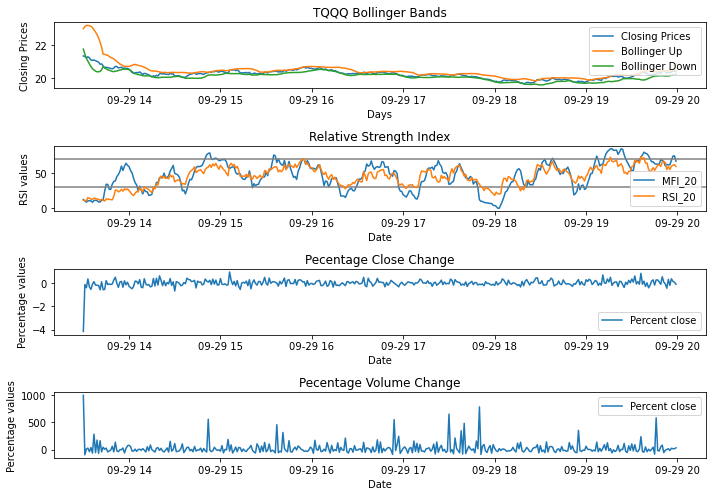

2022-09-30


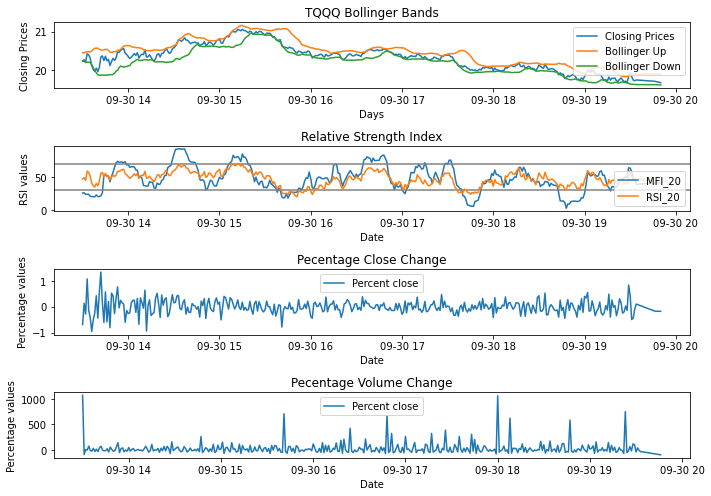

In [19]:
for i in np.unique(hist.index.date):
    print(i)
    sub_hist = hist[str(i):str(i)]

    
    fig = plt.figure(figsize=(10, 7))

    # Define position of 1st subplot
    ax = fig.add_subplot(4, 1, 1)

    # Set the title and axis labels
    plt.title(symbol + ' Bollinger Bands')
    plt.xlabel('Days')
    plt.ylabel('Closing Prices')
    plt.plot(sub_hist['close'], label='Closing Prices')
    plt.plot(sub_hist['bollinger_up_14'], label='Bollinger Up')
    plt.plot(sub_hist['bollinger_down_14'], label='Bollinger Down')
    plt.legend()

    # Define position of 2nd subplot
    bx = fig.add_subplot(4, 1, 2)

    # Set the title and axis labels
    plt.title('Relative Strength Index')
    plt.xlabel('Date')
    plt.ylabel('RSI values')
    
    plt.plot(sub_hist['MFI_14'], label='MFI_20')
    plt.axhline(y=30, color='grey', linestyle='-')
    plt.axhline(y=70, color='grey', linestyle='-')
    plt.plot(sub_hist['RSI_14'], label='RSI_20') 

    # Add a legend to the axis
    plt.legend()

    
    
    cx = fig.add_subplot(4, 1, 3)
    plt.title('Pecentage Close Change')
    plt.xlabel('Date')
    plt.ylabel('Percentage values')
    
    plt.plot(sub_hist['PER_close'], label='Percent close')

    plt.legend()
    

    cx = fig.add_subplot(4, 1, 4)
    plt.title('Pecentage Volume Change')
    plt.xlabel('Date')
    plt.ylabel('Percentage values')
    
    plt.plot(sub_hist['PER_volume'], label='Percent close')

    plt.legend()
    
    
    plt.tight_layout()
    plt.show()
    
    
   

In [20]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,,,,,
2022-09-22 09:30:00-04:00,22.850000,23.080000,22.799999,23.074499,23.074499,15332963,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-22 09:31:00-04:00,23.075001,23.080000,22.959999,23.031099,23.031099,1141120,NaN,NaN,NaN,NaN,-0.188086,-92.557733
2022-09-22 09:32:00-04:00,23.025000,23.069599,22.910000,22.990000,22.990000,923174,NaN,NaN,NaN,NaN,-0.178452,-19.099306
2022-09-22 09:33:00-04:00,23.050301,23.087601,23.049999,23.079300,23.079300,917836,NaN,NaN,NaN,NaN,0.388430,-0.578223
2022-09-22 09:34:00-04:00,23.000000,23.080000,23.000000,23.029699,23.029699,338528,NaN,NaN,NaN,NaN,-0.214914,-63.116722
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30 15:32:00-04:00,19.764999,19.770000,19.733400,19.737801,19.737801,1077597,49.851148,46.077971,19.899094,19.628178,-0.441353,-13.815062
2022-09-30 15:33:00-04:00,19.735001,19.779900,19.719999,19.719999,19.719999,661752,43.864025,44.983654,19.896126,19.622289,-0.090189,-38.590029
2022-09-30 15:34:00-04:00,19.715000,19.750000,19.700001,19.740000,19.740000,401264,39.264698,46.520431,19.891700,19.619572,0.101422,-39.363387


In [21]:
for i in np.unique(hist.index.date):
    print(i)
    sub_hist = hist[str(i):str(i)]

    for i in range(5):
        sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
    sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
    sub_hist['success'] = np.where(sub_hist['close']*1.001 < sub_hist['highest'], 1,0)
    print(sub_hist)

2022-09-22
                                open       high        low      close  \
Datetime                                                                
2022-09-22 09:30:00-04:00  22.850000  23.080000  22.799999  23.074499   
2022-09-22 09:31:00-04:00  23.075001  23.080000  22.959999  23.031099   
2022-09-22 09:32:00-04:00  23.025000  23.069599  22.910000  22.990000   
2022-09-22 09:33:00-04:00  23.050301  23.087601  23.049999  23.079300   
2022-09-22 09:34:00-04:00  23.000000  23.080000  23.000000  23.029699   
...                              ...        ...        ...        ...   
2022-09-22 15:55:00-04:00  22.629900  22.680000  22.466499  22.475000   
2022-09-22 15:56:00-04:00  22.475000  22.535000  22.459999  22.500000   
2022-09-22 15:57:00-04:00  22.500000  22.570000  22.480000  22.535000   
2022-09-22 15:58:00-04:00  22.530100  22.559900  22.530001  22.549500   
2022-09-22 15:59:00-04:00  22.549999  22.549999  22.370001  22.386900   

                            adjclose   

<ipython-input-21-a12d0a408336>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
<ipython-input-21-a12d0a408336>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-21-a12d0a408336>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

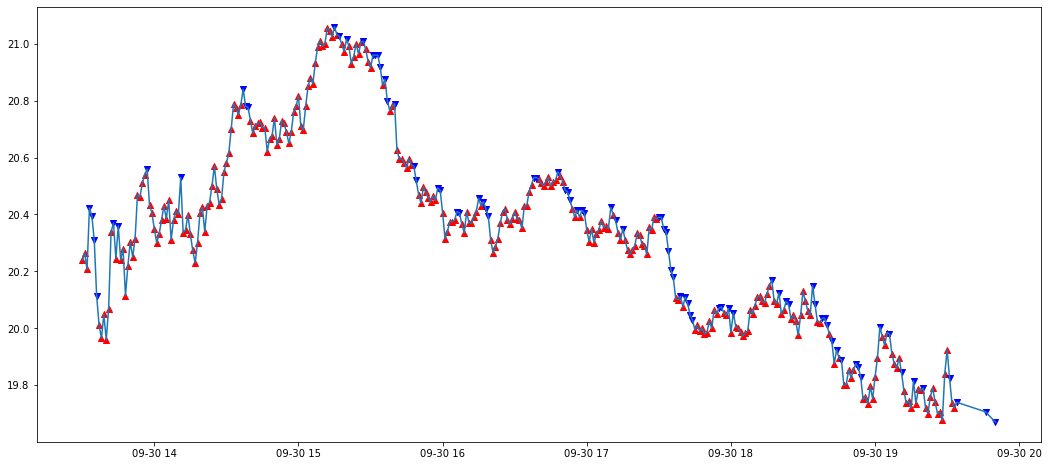

In [22]:
plt.figure(figsize=(18,8))
plt.plot(sub_hist['close'], label='Closing Prices')
plt.scatter(sub_hist[sub_hist['success']==1]['close'].index, sub_hist[sub_hist['success']==1]['close'],label='success', marker = '^', color = 'r')
plt.scatter(sub_hist[sub_hist['success']==0]['close'].index, sub_hist[sub_hist['success']==0]['close'],label='fail', marker = 'v', color = 'b')


In [23]:
sub_hist.groupby(by = 'success').count()

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest
success,,,,,,,,,,,,,,,,,,
0,84,84,84,84,84,84,84,84,84,84,84,83,83,82,81,81,81,83
1,283,283,283,283,283,283,283,283,283,283,283,283,283,283,283,282,281,283


In [24]:
sub_hist.groupby(by = 'success').mean()

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest
success,,,,,,,,,,,,,,,,,,
0,20.319300,20.351398,20.291479,20.323103,20.323103,521150.154762,47.156510,47.574951,20.455477,20.196088,0.021911,16.038770,20.327784,20.304072,20.290535,20.276675,20.263282,20.332593
1,20.331566,20.365446,20.297854,20.330131,20.330131,641194.519435,48.248964,46.810598,20.482632,20.204310,-0.018544,31.836638,20.372765,20.379734,20.383552,20.387368,20.391048,20.430317


In [25]:
sub_hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,
2022-09-30 09:30:00-04:00,20.155001,20.240000,20.080000,20.238501,20.238501,17700882,25.991767,47.168318,20.449429,20.230484,-0.694794,1077.939295,20.299999,20.320000,20.429899,20.438400,20.357599,20.438400,1
2022-09-30 09:31:00-04:00,20.240000,20.299999,20.209999,20.264999,20.264999,987202,26.450223,49.260257,20.451882,20.224475,0.130933,-94.422865,20.320000,20.429899,20.438400,20.357599,20.260000,20.438400,1
2022-09-30 09:32:00-04:00,20.270000,20.320000,20.160601,20.207100,20.207100,1024976,24.079542,45.061743,20.464086,20.198142,-0.285712,3.826370,20.429899,20.438400,20.357599,20.260000,20.029900,20.438400,1
2022-09-30 09:33:00-04:00,20.348200,20.429899,20.330000,20.423100,20.423100,960829,24.199974,59.075277,20.479301,20.203341,1.068929,-6.258390,20.438400,20.357599,20.260000,20.029900,20.040001,20.438400,0
2022-09-30 09:34:00-04:00,20.429199,20.438400,20.379999,20.395000,20.395000,1661036,24.169612,57.037046,20.480989,20.202997,-0.137585,72.875298,20.357599,20.260000,20.029900,20.040001,20.070000,20.357599,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30 15:32:00-04:00,19.764999,19.770000,19.733400,19.737801,19.737801,1077597,49.851148,46.077971,19.899094,19.628178,-0.441353,-13.815062,19.779900,19.750000,19.719999,19.670601,NaN,19.779900,1
2022-09-30 15:33:00-04:00,19.735001,19.779900,19.719999,19.719999,19.719999,661752,43.864025,44.983654,19.896126,19.622289,-0.090189,-38.590029,19.750000,19.719999,19.670601,NaN,NaN,19.750000,1
2022-09-30 15:34:00-04:00,19.715000,19.750000,19.700001,19.740000,19.740000,401264,39.264698,46.520431,19.891700,19.619572,0.101422,-39.363387,19.719999,19.670601,NaN,NaN,NaN,19.719999,0


In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFECV

from imblearn.over_sampling import SMOTE

In [34]:
sub_hist.dropna(axis=0,inplace=True)

<ipython-input-34-ef34d1ed98fe>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist.dropna(axis=0,inplace=True)


In [35]:
X_df = sub_hist[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume']]
y_df = sub_hist['success']

In [36]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,
2022-09-30 09:30:00-04:00,20.238501,17700882,25.991767,47.168318,20.449429,20.230484,-0.694794,1077.939295
2022-09-30 09:31:00-04:00,20.264999,987202,26.450223,49.260257,20.451882,20.224475,0.130933,-94.422865
2022-09-30 09:32:00-04:00,20.207100,1024976,24.079542,45.061743,20.464086,20.198142,-0.285712,3.826370
2022-09-30 09:33:00-04:00,20.423100,960829,24.199974,59.075277,20.479301,20.203341,1.068929,-6.258390
2022-09-30 09:34:00-04:00,20.395000,1661036,24.169612,57.037046,20.480989,20.202997,-0.137585,72.875298
...,...,...,...,...,...,...,...,...
2022-09-30 15:27:00-04:00,19.705000,364834,49.914267,41.530669,19.825659,19.672656,0.024873,-22.606608
2022-09-30 15:28:00-04:00,19.676001,784663,50.160689,39.314791,19.830190,19.658268,-0.147167,115.073979
2022-09-30 15:29:00-04:00,19.840099,1565233,64.076368,54.204903,19.851393,19.654236,0.834005,99.478375


In [37]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.3,
                                  random_state=1)

In [39]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [40]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.500000
1  KNN  0.619220
2  SVC  0.489078
3  GNB  0.469645
4   RF  0.723121
5   GB  0.668582


In [41]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.443787
1  KNN  0.615385
2  SVC  0.455621
3  GNB  0.502959
4   RF  0.727811
5   GB  0.650888


In [42]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.746 (0.039)


In [44]:
n_scores

array([0.7721519 , 0.74683544, 0.78481013, 0.73076923, 0.75641026,
       0.78481013, 0.64556962, 0.78481013, 0.79487179, 0.73076923,
       0.78481013, 0.73417722, 0.72151899, 0.71794872, 0.70512821])

In [45]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\altai\anaconda4\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: [0.68964622 0.72265498 0.71506005 0.75319701 0.6997728         nan
 0.70236936 0.72775073        nan        nan]
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [46]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.7455621301775148

In [50]:
hist['under_BBL'] = np.where(hist['close'] < hist['bollinger_down_14'], 1, 0)

In [51]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,under_BBL
Datetime,,,,,,,,,,,,,
2022-09-22 09:30:00-04:00,22.850000,23.080000,22.799999,23.074499,23.074499,15332963,NaN,NaN,NaN,NaN,NaN,NaN,0
2022-09-22 09:31:00-04:00,23.075001,23.080000,22.959999,23.031099,23.031099,1141120,NaN,NaN,NaN,NaN,-0.188086,-92.557733,0
2022-09-22 09:32:00-04:00,23.025000,23.069599,22.910000,22.990000,22.990000,923174,NaN,NaN,NaN,NaN,-0.178452,-19.099306,0
2022-09-22 09:33:00-04:00,23.050301,23.087601,23.049999,23.079300,23.079300,917836,NaN,NaN,NaN,NaN,0.388430,-0.578223,0
2022-09-22 09:34:00-04:00,23.000000,23.080000,23.000000,23.029699,23.029699,338528,NaN,NaN,NaN,NaN,-0.214914,-63.116722,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30 15:32:00-04:00,19.764999,19.770000,19.733400,19.737801,19.737801,1077597,49.851148,46.077971,19.899094,19.628178,-0.441353,-13.815062,0
2022-09-30 15:33:00-04:00,19.735001,19.779900,19.719999,19.719999,19.719999,661752,43.864025,44.983654,19.896126,19.622289,-0.090189,-38.590029,0
2022-09-30 15:34:00-04:00,19.715000,19.750000,19.700001,19.740000,19.740000,401264,39.264698,46.520431,19.891700,19.619572,0.101422,-39.363387,0


2022-09-22
8 7 0.875


<ipython-input-57-157dfb64d8d4>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
<ipython-input-57-157dfb64d8d4>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-57-157dfb64d8d4>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

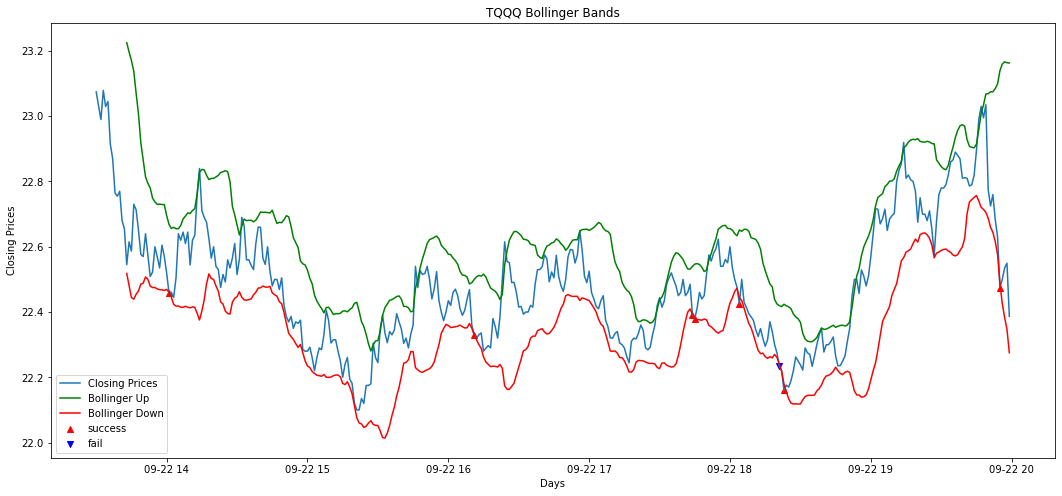

2022-09-23
17 14 0.8235294117647058


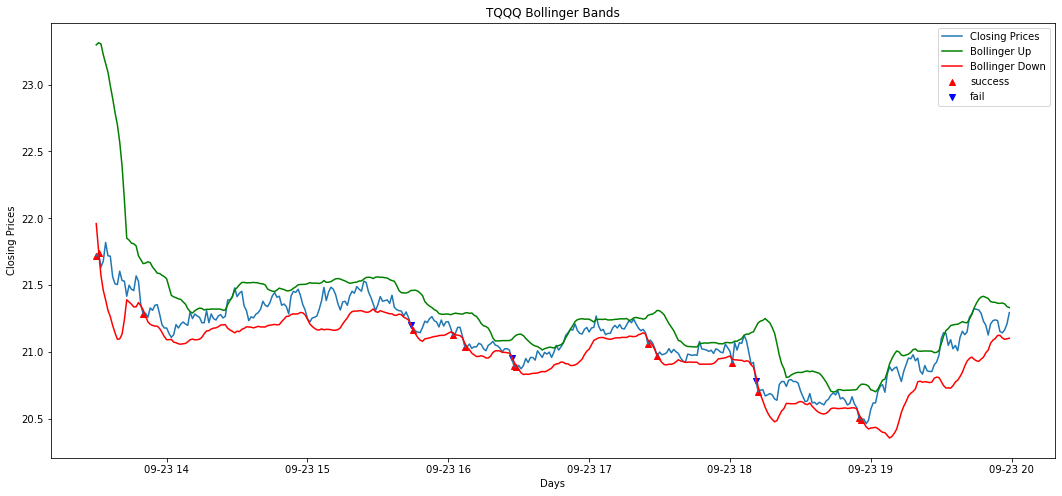

2022-09-26
24 21 0.875


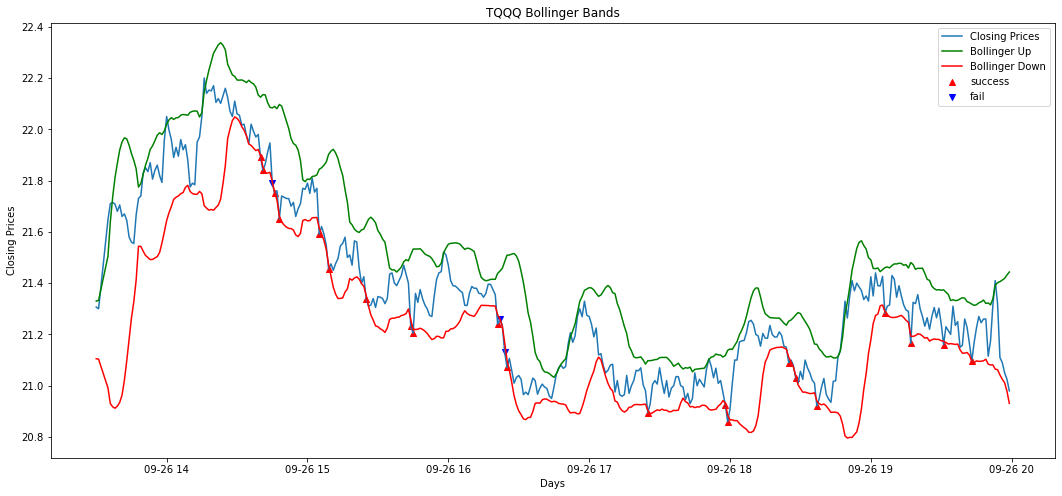

2022-09-27
19 16 0.8421052631578947


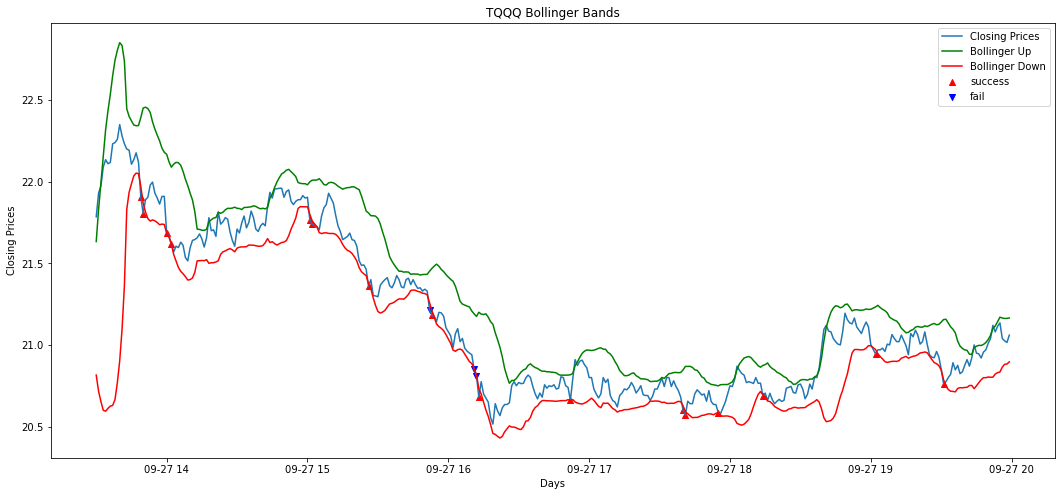

2022-09-28
11 9 0.8181818181818182


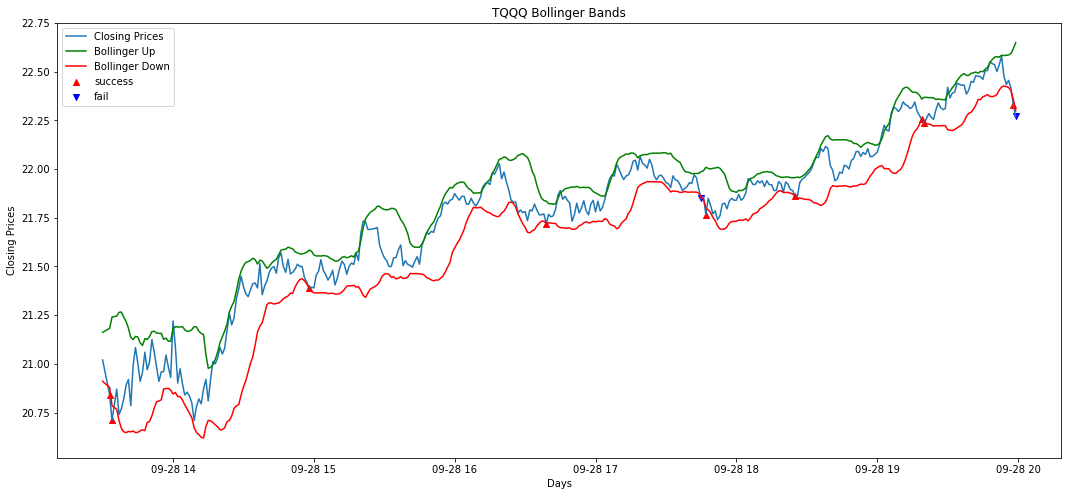

2022-09-29
16 15 0.9375


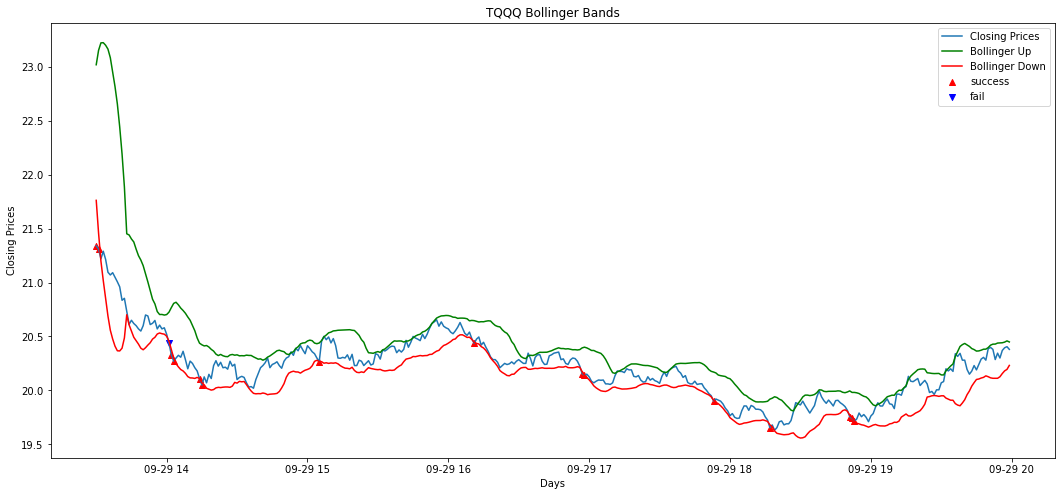

2022-09-30
20 15 0.75


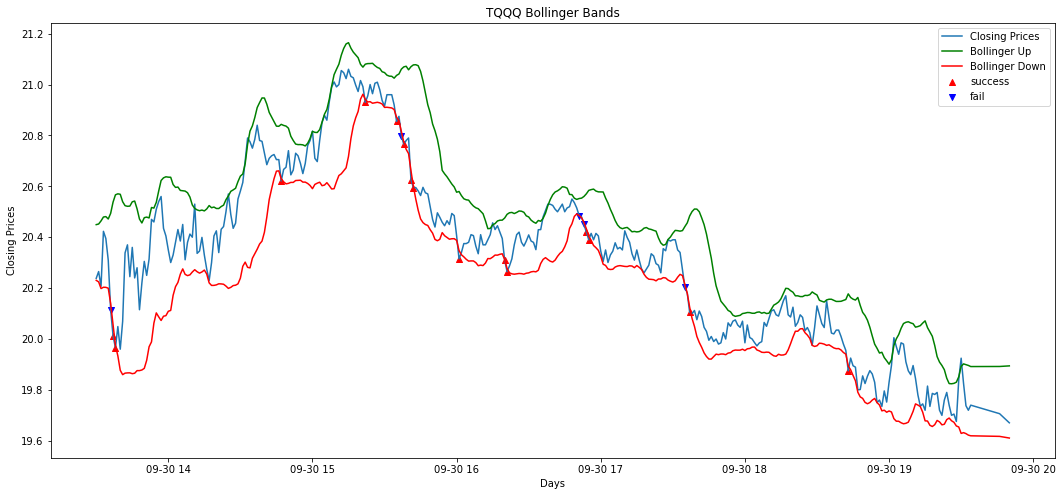

In [57]:
for i in np.unique(hist.index.date):
    print(i)
    sub_hist = hist[str(i):str(i)]

    plt.figure(figsize=(18,8))
    plt.title(symbol + ' Bollinger Bands')
    plt.xlabel('Days')
    plt.ylabel('Closing Prices')
    plt.plot(sub_hist['close'], label='Closing Prices')
    plt.plot(sub_hist['bollinger_up_14'], label='Bollinger Up', c='g')
    plt.plot(sub_hist['bollinger_down_14'], label='Bollinger Down', c='r')
#     plt.scatter(sub_hist[sub_hist['under_BBL']==1]['Close'].index, sub_hist[sub_hist['under_BBL']==1]['Close'],label='under bolligerband_low')

    # plt.plot(closing_prices, label='Closing Prices')
    # plt.plot(bollinger_up, label='Bollinger Up', c='g')
    # plt.plot(bollinger_down, label='Bollinger Down', c='r')

    
    
    for i in range(5):
        sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
    sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
    sub_hist['success'] = np.where((sub_hist['under_BBL'] == 1) & (sub_hist['close']*1.001 < sub_hist['highest']), 1,0)
    
    print(len(sub_hist[sub_hist['under_BBL']==1]), len(sub_hist[sub_hist['success']==1]), len(sub_hist[sub_hist['success']==1])/len(sub_hist[sub_hist['under_BBL']==1]))
    plt.scatter(sub_hist[sub_hist['success']==1]['close'].index, sub_hist[sub_hist['success']==1]['close'],label='success', marker = '^', color = 'r')
    plt.scatter(sub_hist[(sub_hist['success']==0) & (sub_hist['under_BBL']==1)]['close'].index, sub_hist[(sub_hist['success']==0) & (sub_hist['under_BBL']==1)]['close'],label='fail', marker = 'v', color = 'b')
    
    plt.legend()
    plt.show()